# Pill Image Classification with MobileNetV3

**Project objective:** develop a prototype visual quality-control classifier that identifies a medication from an image of a pill across 84 known classes, reducing the need for manual verification.


## Stage 1. Library and Dataset Loading

In [ ]:
import os
import random
import shutil
import time
import zipfile
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from google.colab import drive
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import StratifiedShuffleSplit
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torchvision.models import MobileNet_V3_Small_Weights, mobilenet_v3_small


In [ ]:
# Reproducibility configuration.
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


In [ ]:
# Google Colab environment and GPU availability check.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
# Reproducible and validated data-loading configuration.
# Update this path only if your ZIP archive has a different name or location in Google Drive.
drive.mount('/content/drive')

ZIP_PATH = Path('/content/drive/MyDrive/path/to/tablets.zip')
EXTRACT_DIR = Path('/content/pill_dataset')

# Remove prior extracted copies to avoid using stale files from an earlier run.
if EXTRACT_DIR.exists():
    shutil.rmtree(EXTRACT_DIR)
EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)

# Find the dataset root rather than relying on a hard-coded inner folder name.
candidate_roots = [
    train_path.parent
    for train_path in EXTRACT_DIR.rglob('train')
    if train_path.is_dir() and (train_path.parent / 'test').is_dir()
]

if len(candidate_roots) != 1:
    raise RuntimeError(
        'Expected exactly one dataset root containing train/ and test/ folders; '
        f'found {len(candidate_roots)}: {candidate_roots}'
    )

DATASET_ROOT = candidate_roots[0]
TRAIN_DIR = DATASET_ROOT / 'train'
TEST_DIR = DATASET_ROOT / 'test'


In [ ]:
# Consistent preprocessing, class-mapping checks, and a separate validation split.
# The external test set is reserved for final evaluation.

IMAGE_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 2
PIN_MEMORY = torch.cuda.is_available()
VALIDATION_FRACTION = 0.20

# MobileNetV3-small was pretrained on ImageNet; use the corresponding normalization.
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

train_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.RandomHorizontalFlip(p=0.2),
    transforms.RandomAffine(
        degrees=5,
        translate=(0.02, 0.02),
        fill=(255, 255, 255),
    ),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])


class TransformDataset(Dataset):
    def __init__(self, dataset, transform):
        self.dataset = dataset
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, index):
        image, label = self.dataset[index]
        return self.transform(image), label


train_dataset_raw = ImageFolder(TRAIN_DIR)
test_dataset_raw = ImageFolder(TEST_DIR)

# Integer labels must refer to the same drug names in every data split.
assert train_dataset_raw.classes == test_dataset_raw.classes, (
    'Train and test folders have different class-to-index mappings.'
)

all_indices = np.arange(len(train_dataset_raw))
all_targets = np.asarray(train_dataset_raw.targets)
splitter = StratifiedShuffleSplit(
    n_splits=1,
    test_size=VALIDATION_FRACTION,
    random_state=SEED,
)
train_indices, val_indices = next(splitter.split(all_indices, all_targets))

train_dataset = TransformDataset(Subset(train_dataset_raw, train_indices), train_transforms)
val_dataset = TransformDataset(Subset(train_dataset_raw, val_indices), eval_transforms)
test_dataset = TransformDataset(test_dataset_raw, eval_transforms)


def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % (2**32)
    np.random.seed(worker_seed)
    random.seed(worker_seed)


loader_generator = torch.Generator().manual_seed(SEED)
loader_kwargs = {
    'num_workers': NUM_WORKERS,
    'pin_memory': PIN_MEMORY,
    'worker_init_fn': seed_worker,
}
if NUM_WORKERS > 0:
    loader_kwargs['persistent_workers'] = True

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    generator=loader_generator,
    **loader_kwargs,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    **loader_kwargs,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    **loader_kwargs,
)

class_counts = Counter(all_targets[train_indices])
print(f'Number of classes: {len(train_dataset_raw.classes)}')
print(f'Training images: {len(train_dataset)}')
print(f'Validation images: {len(val_dataset)}')
print(f'Final test images: {len(test_dataset)}')
print(f'Train examples per class: min={min(class_counts.values())}, max={max(class_counts.values())}')

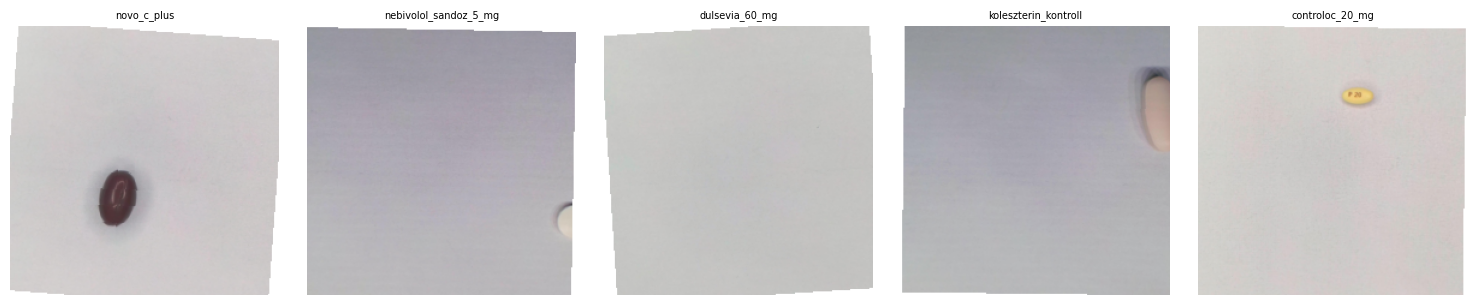

In [ ]:
# Inspect a few normalized training images after applying the new augmentation pipeline.
def denormalize(image_tensor):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return (image_tensor.cpu() * std + mean).clamp(0, 1)

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for ax, index in zip(axes, range(5)):
    image, label = train_dataset[index]
    ax.imshow(denormalize(image).permute(1, 2, 0))
    ax.set_title(train_dataset_raw.classes[label], fontsize=7)
    ax.axis('off')
plt.tight_layout()
plt.show()


## Stage 2. Model Definition

In [ ]:
# Preserve the pretrained classifier stem and replace only the final output layer
# for the 84 target classes.

weights = MobileNet_V3_Small_Weights.IMAGENET1K_V1
model = mobilenet_v3_small(weights=weights)
num_classes = len(train_dataset_raw.classes)

model.classifier[3] = nn.Linear(
    in_features=model.classifier[3].in_features,
    out_features=num_classes,
)
model.to(device)

print(f'Number of target classes: {num_classes}')
print(f'Final classifier layer: {model.classifier[3]}')

## Stage 3. Training and Fine-Tuning

In [ ]:
# Two-stage fine-tuning with validation accuracy, numeric loss accumulation,
# a learning-rate scheduler, early stopping, and checkpointing.

CHECKPOINT_DIR = Path('/content/pill_checkpoints')
CHECKPOINT_DIR.mkdir(exist_ok=True)
HEAD_CHECKPOINT = CHECKPOINT_DIR / 'best_head.pt'
FINETUNED_CHECKPOINT = CHECKPOINT_DIR / 'best_finetuned.pt'

HEAD_EPOCHS = 8
FINE_TUNE_EPOCHS = 20
PATIENCE = 6
MIN_DELTA = 1e-4

criterion = nn.CrossEntropyLoss()
history = {
    'phase': [],
    'epoch': [],
    'train_loss': [],
    'val_loss': [],
    'val_accuracy': [],
    'learning_rate': [],
    'epoch_seconds': [],
}


def set_trainable_layers(model, phase):
    for parameter in model.parameters():
        parameter.requires_grad = False

    if phase == 'head':
        for parameter in model.classifier.parameters():
            parameter.requires_grad = True
        return optim.AdamW(model.classifier.parameters(), lr=1e-3, weight_decay=1e-4)

    if phase == 'fine_tune':
        for parameter in model.features[-3:].parameters():
            parameter.requires_grad = True
        for parameter in model.classifier.parameters():
            parameter.requires_grad = True
        return optim.AdamW(
            [
                {'params': model.features[-3:].parameters(), 'lr': 1e-5},
                {'params': model.classifier.parameters(), 'lr': 1e-4},
            ],
            weight_decay=1e-4,
        )

    raise ValueError(f'Unknown phase: {phase}')


def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    total_examples = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=PIN_MEMORY)
        labels = labels.to(device, non_blocking=PIN_MEMORY)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        current_batch_size = labels.size(0)
        total_loss += loss.item() * current_batch_size
        total_examples += current_batch_size

    return total_loss / total_examples


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=PIN_MEMORY)
            labels = labels.to(device, non_blocking=PIN_MEMORY)

            logits = model(images)
            loss = criterion(logits, labels)
            predictions = logits.argmax(dim=1)

            current_batch_size = labels.size(0)
            total_loss += loss.item() * current_batch_size
            total_correct += (predictions == labels).sum().item()
            total_examples += current_batch_size

    return total_loss / total_examples, total_correct / total_examples


def save_checkpoint(path, model, optimizer, epoch, phase, val_loss, val_accuracy):
    torch.save(
        {
            'epoch': epoch,
            'phase': phase,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': val_loss,
            'val_accuracy': val_accuracy,
            'class_names': train_dataset_raw.classes,
            'seed': SEED,
        },
        path,
    )


def fit(model, phase, max_epochs, checkpoint_path, min_epochs=1):
    optimizer = set_trainable_layers(model, phase)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=0.5,
        patience=2,
    )

    best_val_loss = float('inf')
    epochs_without_improvement = 0

    for epoch in range(1, max_epochs + 1):
        start_time = time.perf_counter()
        train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_accuracy = evaluate(model, val_loader, criterion, device)
        elapsed_seconds = time.perf_counter() - start_time
        learning_rate = optimizer.param_groups[-1]['lr']

        scheduler.step(val_loss)
        history['phase'].append(phase)
        history['epoch'].append(epoch)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_accuracy'].append(val_accuracy)
        history['learning_rate'].append(learning_rate)
        history['epoch_seconds'].append(elapsed_seconds)

        if val_loss < best_val_loss - MIN_DELTA:
            best_val_loss = val_loss
            epochs_without_improvement = 0
            save_checkpoint(
                checkpoint_path,
                model,
                optimizer,
                epoch,
                phase,
                val_loss,
                val_accuracy,
            )
            checkpoint_status = 'saved'
        else:
            epochs_without_improvement += 1
            checkpoint_status = f'no improvement ({epochs_without_improvement}/{PATIENCE})'

        print(
            f'{phase:>9} | epoch {epoch:02d}/{max_epochs} | '
            f'train loss: {train_loss:.4f} | val loss: {val_loss:.4f} | '
            f'val accuracy: {val_accuracy:.4f} | time: {elapsed_seconds:.1f}s | '
            f'checkpoint: {checkpoint_status}'
        )

        if epoch >= min_epochs and epochs_without_improvement >= PATIENCE:
            print(f'Early stopping triggered during {phase} fine-tuning.')
            break

    return checkpoint_path


# Phase 1: train the classifier while freezing the pretrained feature extractor.
fit(model, phase='head', max_epochs=HEAD_EPOCHS, checkpoint_path=HEAD_CHECKPOINT)

# Restore the strongest classifier-head model before unfreezing the final feature blocks.
head_checkpoint = torch.load(HEAD_CHECKPOINT, map_location=device, weights_only=True)
model.load_state_dict(head_checkpoint['model_state_dict'])

# Phase 2: fine-tune the final feature blocks with a smaller learning rate.
fit(
    model,
    phase='fine_tune',
    max_epochs=FINE_TUNE_EPOCHS,
    checkpoint_path=FINETUNED_CHECKPOINT,
    min_epochs=8,
)


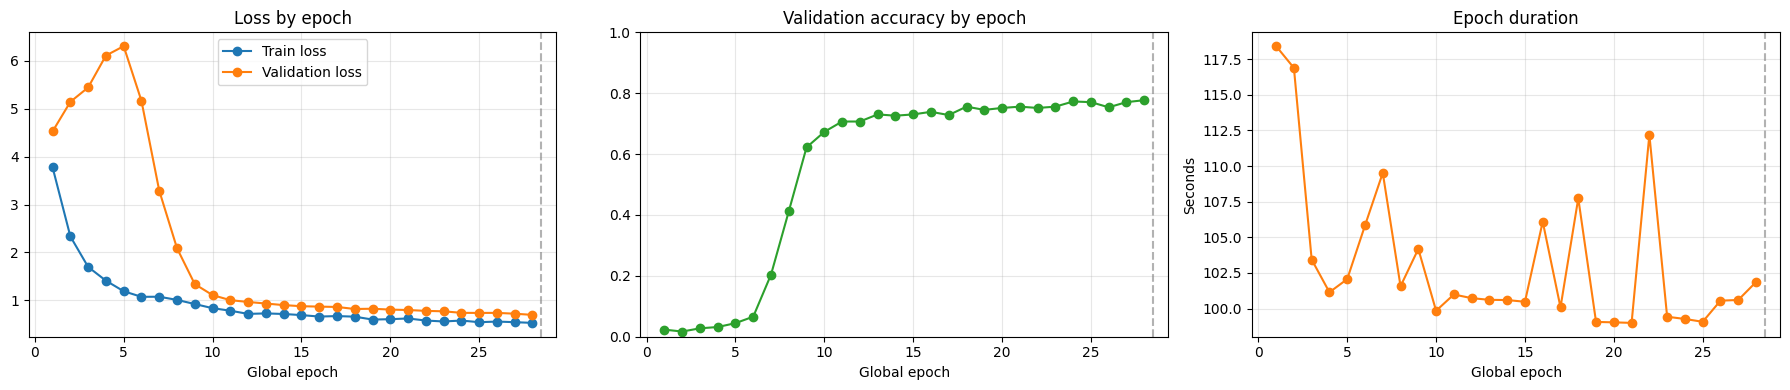

val_loss                     val_accuracy                     \
                min       max      mean          min      max      mean   
phase                                                                     
fine_tune  0.697133  1.339682  0.865521     0.622081  0.77707  0.736200   
head       2.089501  6.308034  4.760834     0.016985  0.41189  0.103238   

          epoch_seconds                          
                    min         max        mean  
phase                                            
fine_tune     98.996119  112.200943  101.573068  
head         101.145483  118.415337  107.359835

In [ ]:
# Learning curves across both fine-tuning phases.
history_df = pd.DataFrame(history)
history_df['global_epoch'] = np.arange(1, len(history_df) + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
axes[0].plot(history_df['global_epoch'], history_df['train_loss'], marker='o', label='Train loss')
axes[0].plot(history_df['global_epoch'], history_df['val_loss'], marker='o', label='Validation loss')
axes[0].set_title('Loss by epoch')
axes[0].set_xlabel('Global epoch')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history_df['global_epoch'], history_df['val_accuracy'], marker='o', color='tab:green')
axes[1].set_title('Validation accuracy by epoch')
axes[1].set_xlabel('Global epoch')
axes[1].set_ylim(0, 1)
axes[1].grid(alpha=0.3)

axes[2].plot(history_df['global_epoch'], history_df['epoch_seconds'], marker='o', color='tab:orange')
axes[2].set_title('Epoch duration')
axes[2].set_xlabel('Global epoch')
axes[2].set_ylabel('Seconds')
axes[2].grid(alpha=0.3)

for phase_end in history_df.groupby('phase')['global_epoch'].max().iloc[:-1]:
    for ax in axes:
        ax.axvline(phase_end + 0.5, color='gray', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

history_df.groupby('phase')[['val_loss', 'val_accuracy', 'epoch_seconds']].agg(['min', 'max', 'mean'])


## Stage 4. Model Evaluation

In [ ]:
# Safe final-checkpoint loading and a single, untouched external test-set evaluation.
# Select the globally best checkpoint rather than assuming that phase 2 always improves phase 1.
candidate_paths = [HEAD_CHECKPOINT, FINETUNED_CHECKPOINT]
existing_checkpoints = [path for path in candidate_paths if path.is_file()]

if not existing_checkpoints:
    raise FileNotFoundError(
        'No checkpoint was found. Run the training cell before final evaluation.'
    )

loaded_checkpoints = {
    path: torch.load(path, map_location=device, weights_only=True)
    for path in existing_checkpoints
}
FINAL_CHECKPOINT, checkpoint = min(
    loaded_checkpoints.items(),
    key=lambda item: item[1]['val_loss'],
)

model.load_state_dict(checkpoint['model_state_dict'])
model.to(device)
model.eval()

if checkpoint['class_names'] != test_dataset_raw.classes:
    raise ValueError('Checkpoint class mapping differs from the final test-set mapping.')

print(
    f"Loaded overall best {checkpoint['phase']} checkpoint from epoch {checkpoint['epoch']} | "
    f"validation loss: {checkpoint['val_loss']:.4f} | "
    f"validation accuracy: {checkpoint['val_accuracy']:.4f}"
)

labels_true = []
labels_predicted = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device, non_blocking=PIN_MEMORY)
        logits = model(images)
        predictions = logits.argmax(dim=1).cpu().numpy()

        labels_predicted.extend(predictions)
        labels_true.extend(labels.numpy())

test_accuracy = (np.asarray(labels_true) == np.asarray(labels_predicted)).mean()
print(f'Final test accuracy: {test_accuracy:.4f}')

report_dict = classification_report(
    labels_true,
    labels_predicted,
    target_names=checkpoint['class_names'],
    output_dict=True,
    zero_division=0,
)
report_df = (
    pd.DataFrame(report_dict)
    .T
    .drop(index=['accuracy', 'macro avg', 'weighted avg'])
    .sort_values('recall')
)
report_df.head(10)


Loaded overall best fine_tune checkpoint from epoch 20 | validation loss: 0.6971 | validation accuracy: 0.7771
Final test accuracy: 0.7679


,precision,recall,f1-score,support
novo_c_plus,0.333333,0.166667,0.222222,6.0
cataflam_50_mg,1.000000,0.333333,0.500000,6.0
nebivolol_sandoz_5_mg,0.666667,0.333333,0.444444,6.0
enterol_250_mg,0.500000,0.333333,0.400000,6.0
vitamin_d3_fresenius_1000_ne,1.000000,0.333333,0.500000,6.0
concor_5_mg,1.000000,0.500000,0.666667,6.0
controloc_20_mg,0.750000,0.500000,0.600000,6.0
covercard_plus_10_mg_2_5_mg_5_mg,0.500000,0.500000,0.500000,6.0
lordestin_5_mg,1.000000,0.500000,0.666667,6.0
milurit_300_mg,0.600000,0.500000,0.545455,6.0


Five classes with the lowest recall:


,precision,recall,f1-score,support
novo_c_plus,0.333333,0.166667,0.222222,6
cataflam_50_mg,1.000000,0.333333,0.500000,6
nebivolol_sandoz_5_mg,0.666667,0.333333,0.444444,6
enterol_250_mg,0.500000,0.333333,0.400000,6
vitamin_d3_fresenius_1000_ne,1.000000,0.333333,0.500000,6


novo_c_plus: 2/6 samples were most often predicted as dulsevia_60_mg.
cataflam_50_mg: 2/6 samples were most often predicted as cetirizin_10_mg.
nebivolol_sandoz_5_mg: 3/6 samples were most often predicted as naturland_d_vitamin_forte.
enterol_250_mg: 3/6 samples were most often predicted as meridian.
vitamin_d3_fresenius_1000_ne: 1/6 samples were most often predicted as milurit_300_mg.


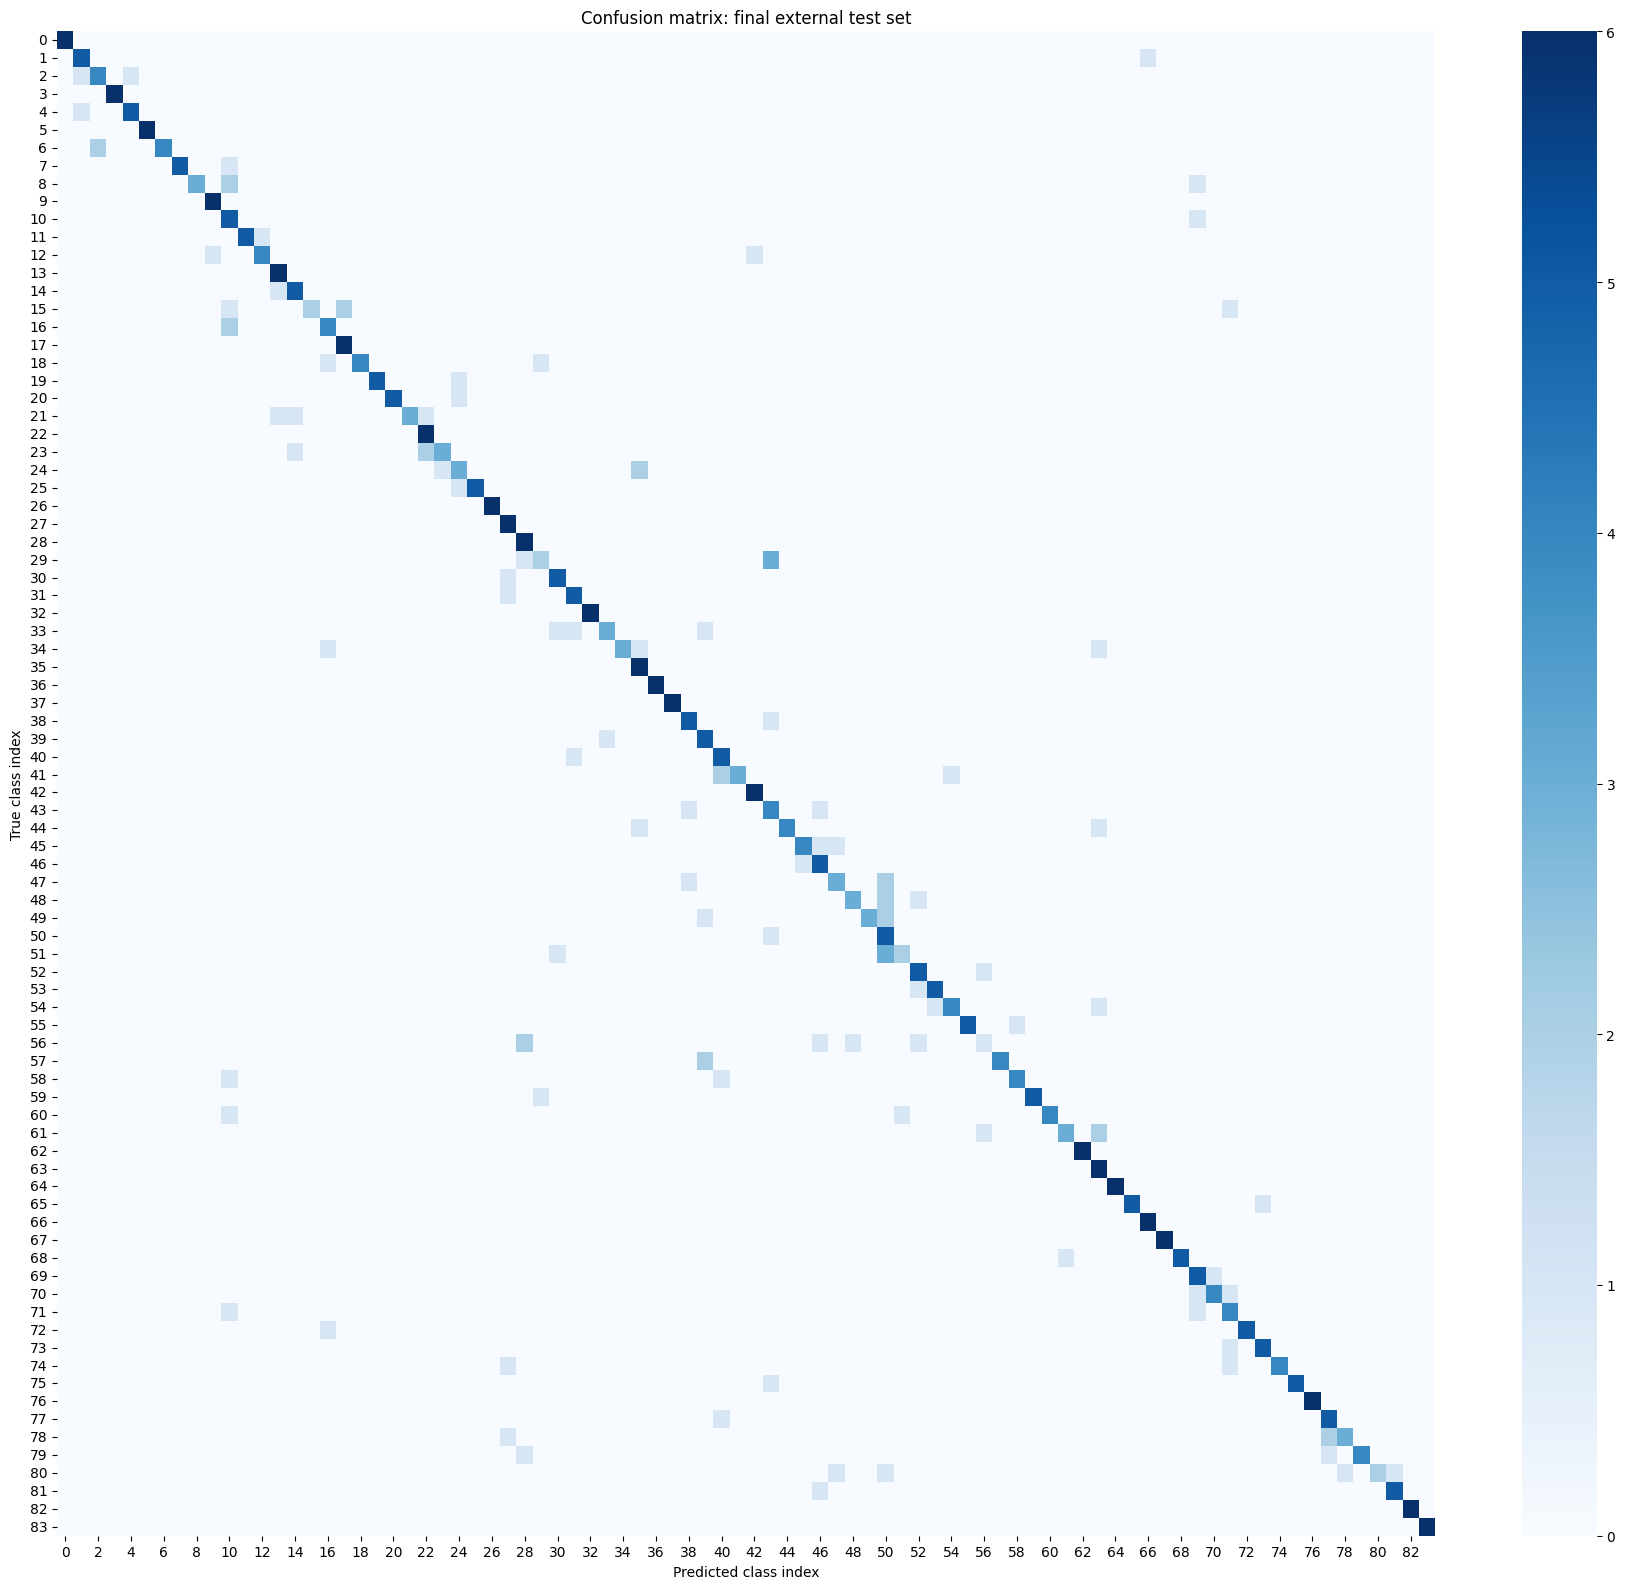

In [ ]:
# Error analysis based on the new final-test predictions.
class_names = checkpoint['class_names']
cm = confusion_matrix(labels_true, labels_predicted, labels=np.arange(len(class_names)))

per_class_metrics = report_df.copy()
per_class_metrics['support'] = per_class_metrics['support'].astype(int)
worst_classes = per_class_metrics.head(5)

print('Five classes with the lowest recall:')
display(worst_classes[['precision', 'recall', 'f1-score', 'support']])

# Report the most frequent wrong predicted label for each of the five weakest classes.
for actual_class, metrics in worst_classes.iterrows():
    actual_idx = class_names.index(actual_class)
    row = cm[actual_idx].copy()
    row[actual_idx] = 0
    predicted_idx = row.argmax()
    mistakes = row[predicted_idx]

    if mistakes == 0:
        print(f'{actual_class}: no errors in the final test set.')
    else:
        print(
            f"{actual_class}: {mistakes}/{int(metrics['support'])} samples were most often "
            f"predicted as {class_names[predicted_idx]}."
        )

# A full 84 x 84 matrix is dense; the heatmap remains available for diagnostic use.
plt.figure(figsize=(18, 16))
sns.heatmap(cm, cmap='Blues', cbar=True)
plt.title('Confusion matrix: final external test set')
plt.xlabel('Predicted class index')
plt.ylabel('True class index')
plt.tight_layout()
plt.show()


## Results and conclusions after the revised run

Run the notebook from top to bottom before completing this section. The previous conclusion based on an earlier pipeline has been intentionally removed because the data split, preprocessing, model head, and fine-tuning strategy have changed.

Use the values printed by the final evaluation cell to document:

- the best validation checkpoint, including its phase, epoch, validation loss, and validation accuracy;
- final accuracy on the untouched external test set;
- the five classes with the lowest recall and their most frequent confusions;
- whether the learning curves indicate underfitting, overfitting, or stable convergence;
- the measured epoch duration and whether the expected GPU was active.

> **Methodological note:** do not interpret an unsuccessful run through the confusion matrix as evidence of visual similarity between classes. First establish that the model achieves a meaningful test accuracy; then investigate class-level errors using the new final-test predictions.
